# TV2 – Class Imbalance & EDA
**Người thực hiện:** (TV2)  
**Dataset:** Give Me Some Credit – Kaggle  
**Mục tiêu notebook này:**
- Minh hoạ vấn đề class imbalance và vì sao accuracy gây hiểu lầm
- Làm EDA cơ bản: class distribution, missing values, feature histograms, correlation heatmap
- Lưu hình vào `outputs/figures/` đúng tên chuẩn của nhóm

---
> **Lưu ý chạy:** Đặt notebook này ở thư mục gốc project (cùng cấp với `data/` và `outputs/`).  
> Chạy từ đầu đến cuối theo thứ tự. Không cần chạy gì trước.

## 0. Setup – Import thư viện và cấu hình đường dẫn

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import os
import warnings

warnings.filterwarnings('ignore')

# ── Cấu hình style ──────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})
PALETTE = ['#2ecc71', '#e74c3c']   # xanh = không rủi ro, đỏ = rủi ro
RANDOM_STATE = 42

# ── Đường dẫn ────────────────────────────────────────────────────
DATA_PATH    = os.path.join('data', 'raw', 'cs-training.csv')
OUTPUT_DIR   = os.path.join('outputs', 'figures')
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('Thư viện đã sẵn sàng.')
print(f'Đọc dữ liệu từ : {DATA_PATH}')
print(f'Lưu hình vào   : {OUTPUT_DIR}')

Thư viện đã sẵn sàng.
Đọc dữ liệu từ : data\raw\cs-training.csv
Lưu hình vào   : outputs\figures


## 1. Đọc dữ liệu

In [2]:
df = pd.read_csv(DATA_PATH, index_col=0)   # cột đầu là index (Unnamed: 0)

print(f'Shape: {df.shape}  →  {df.shape[0]:,} dòng  |  {df.shape[1]} cột')
print()
df.head(3)

Shape: (150000, 11)  →  150,000 dòng  |  11 cột



,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0


In [3]:
# Kiểu dữ liệu & missing values tổng quan
info = pd.DataFrame({
    'dtype'      : df.dtypes,
    'non_null'   : df.notna().sum(),
    'null_count' : df.isna().sum(),
    'null_%'     : (df.isna().mean() * 100).round(2),
})
print(info.to_string())

                                        dtype  non_null  null_count  null_%
SeriousDlqin2yrs                        int64    150000           0    0.00
RevolvingUtilizationOfUnsecuredLines  float64    150000           0    0.00
age                                     int64    150000           0    0.00
NumberOfTime30-59DaysPastDueNotWorse    int64    150000           0    0.00
DebtRatio                             float64    150000           0    0.00
MonthlyIncome                         float64    120269       29731   19.82
NumberOfOpenCreditLinesAndLoans         int64    150000           0    0.00
NumberOfTimes90DaysLate                 int64    150000           0    0.00
NumberRealEstateLoansOrLines            int64    150000           0    0.00
NumberOfTime60-89DaysPastDueNotWorse    int64    150000           0    0.00
NumberOfDependents                    float64    146076        3924    2.62


---
## 2. Class Imbalance – Lý thuyết nền

### 2.1 Ví dụ minh hoạ accuracy fail

Giả sử có 10 000 mẫu: 9 900 bình thường và 100 rủi ro.  
Một model "lười" chỉ predict toàn là 0 (không rủi ro) vẫn đạt accuracy = **99%**.  
Nhưng recall với minority class = **0%** – tức là bỏ sót hoàn toàn tất cả người có nguy cơ vỡ nợ.

In [4]:
# ── Ví dụ accuracy fail (không cần chạy model thật) ─────────────
n_normal = 9_900
n_risk   = 100
n_total  = n_normal + n_risk

# Model lười: predict toàn bộ là 0
acc_lazy   = n_normal / n_total
recall_lazy = 0 / n_risk          # không phát hiện được ca nào rủi ro

print('=== Ví dụ accuracy fail ===')
print(f'Tổng mẫu      : {n_total:,}')
print(f'  Bình thường : {n_normal:,} ({n_normal/n_total:.1%})')
print(f'  Rủi ro      : {n_risk:,}  ({n_risk/n_total:.1%})')
print()
print(f'Model "predict tất cả = 0":')  
print(f'  Accuracy = {acc_lazy:.1%}   ← trông rất tốt!')
print(f'  Recall (rủi ro) = {recall_lazy:.1%}  ← không phát hiện được ca nào!')
print()
print('→ Accuracy là metric gây hiểu lầm trên dữ liệu mất cân bằng.')

=== Ví dụ accuracy fail ===
Tổng mẫu      : 10,000
  Bình thường : 9,900 (99.0%)
  Rủi ro      : 100  (1.0%)

Model "predict tất cả = 0":
  Accuracy = 99.0%   ← trông rất tốt!
  Recall (rủi ro) = 0.0%  ← không phát hiện được ca nào!

→ Accuracy là metric gây hiểu lầm trên dữ liệu mất cân bằng.


---
## 3. Hình 1 – Phân phối target (Class Distribution)

**Caption:** *Hình 1 – Phân phối nhãn target `SeriousDlqin2yrs` trong tập huấn luyện (150 000 mẫu).  
Lớp 0 (không rủi ro) chiếm ~93.3%, lớp 1 (rủi ro) chỉ ~6.7%, tạo ra tỷ lệ minority:majority xấp xỉ 1:14.*

Đã lưu: outputs\figures\dm_gmsc_class_distribution.png


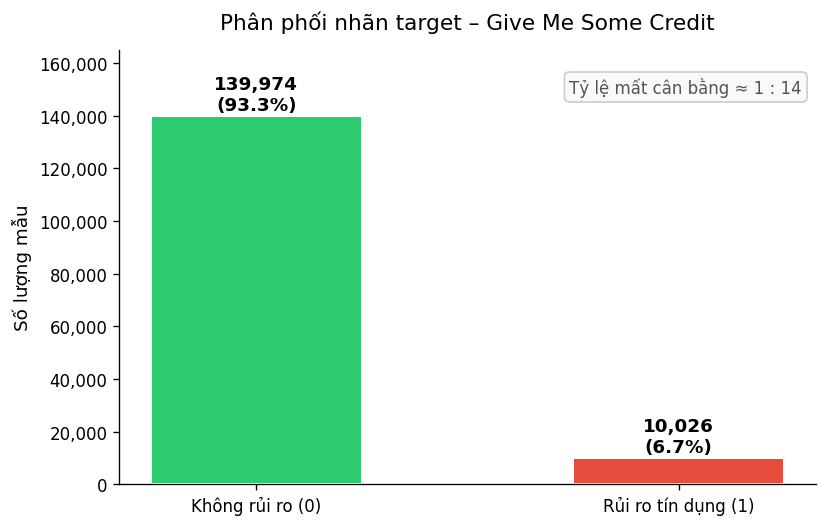

In [5]:
TARGET = 'SeriousDlqin2yrs'

counts = df[TARGET].value_counts().sort_index()
labels = ['Không rủi ro (0)', 'Rủi ro tín dụng (1)']
pcts   = counts / counts.sum() * 100

fig, ax = plt.subplots(figsize=(7, 4.5))

bars = ax.bar(labels, counts.values, color=PALETTE, edgecolor='white', linewidth=1.2, width=0.5)

# Annotate giá trị + %
for bar, cnt, pct in zip(bars, counts.values, pcts.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 600,
            f'{cnt:,}\n({pct:.1f}%)',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Phân phối nhãn target – Give Me Some Credit', fontsize=13, pad=12)
ax.set_ylabel('Số lượng mẫu', fontsize=11)
ax.set_ylim(0, counts.max() * 1.18)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Thêm annotation tỷ lệ
ax.annotate('Tỷ lệ mất cân bằng ≈ 1 : 14',
            xy=(0.98, 0.90), xycoords='axes fraction',
            ha='right', fontsize=10, color='#555',
            bbox=dict(boxstyle='round,pad=0.3', fc='#f9f9f9', ec='#ccc'))

plt.tight_layout()
save_path = os.path.join(OUTPUT_DIR, 'dm_gmsc_class_distribution.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f'Đã lưu: {save_path}')
plt.show()

---
## 4. Hình 2 – Missing Values

**Caption:** *Hình 2 – Tỷ lệ giá trị khuyết thiếu theo từng biến.  
`MonthlyIncome` có ~19.8% giá trị NULL (29 731 dòng), `NumberOfDependents` có ~2.6% (3 924 dòng).  
Các biến còn lại không có missing values và không cần xử lý thêm.*

Đã lưu: outputs\figures\dm_gmsc_missing_values.png


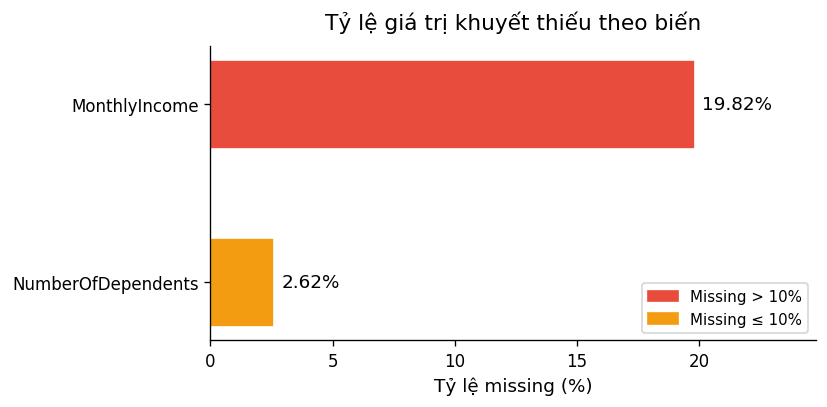

In [6]:
missing = (df.isna().mean() * 100).sort_values(ascending=True)
missing = missing[missing > 0]   # chỉ giữ cột có missing

fig, ax = plt.subplots(figsize=(7, 3.5))

colors = ['#e74c3c' if v > 10 else '#f39c12' for v in missing.values]
bars   = ax.barh(missing.index, missing.values, color=colors, edgecolor='white', height=0.5)

for bar, val in zip(bars, missing.values):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}%', va='center', fontsize=11)

ax.set_xlim(0, missing.max() * 1.25)
ax.set_xlabel('Tỷ lệ missing (%)', fontsize=11)
ax.set_title('Tỷ lệ giá trị khuyết thiếu theo biến', fontsize=13, pad=10)

# Legend
p1 = mpatches.Patch(color='#e74c3c', label='Missing > 10%')
p2 = mpatches.Patch(color='#f39c12', label='Missing ≤ 10%')
ax.legend(handles=[p1, p2], fontsize=9, loc='lower right')

plt.tight_layout()
save_path = os.path.join(OUTPUT_DIR, 'dm_gmsc_missing_values.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f'Đã lưu: {save_path}')
plt.show()

---
## 5. Hình 3 – Phân phối một số feature tài chính quan trọng

**Caption:** *Hình 3 – Phân phối của 4 biến tài chính quan trọng, phân tách theo nhãn target.  
Nhóm rủi ro (đỏ) có xu hướng tập trung ở vùng `RevolvingUtilization` cao, số lần trễ hạn nhiều hơn,  
trong khi `age` và `MonthlyIncome` phânPhần lớn các biến thể hiện xu hướng lệch phải, đặc biệt là `RevolvingUtilizationOfUnsecuredLines` và các biến liên quan đến lịch sử trễ hạn.*

Đã lưu: outputs\figures\dm_gmsc_key_feature_histograms.png


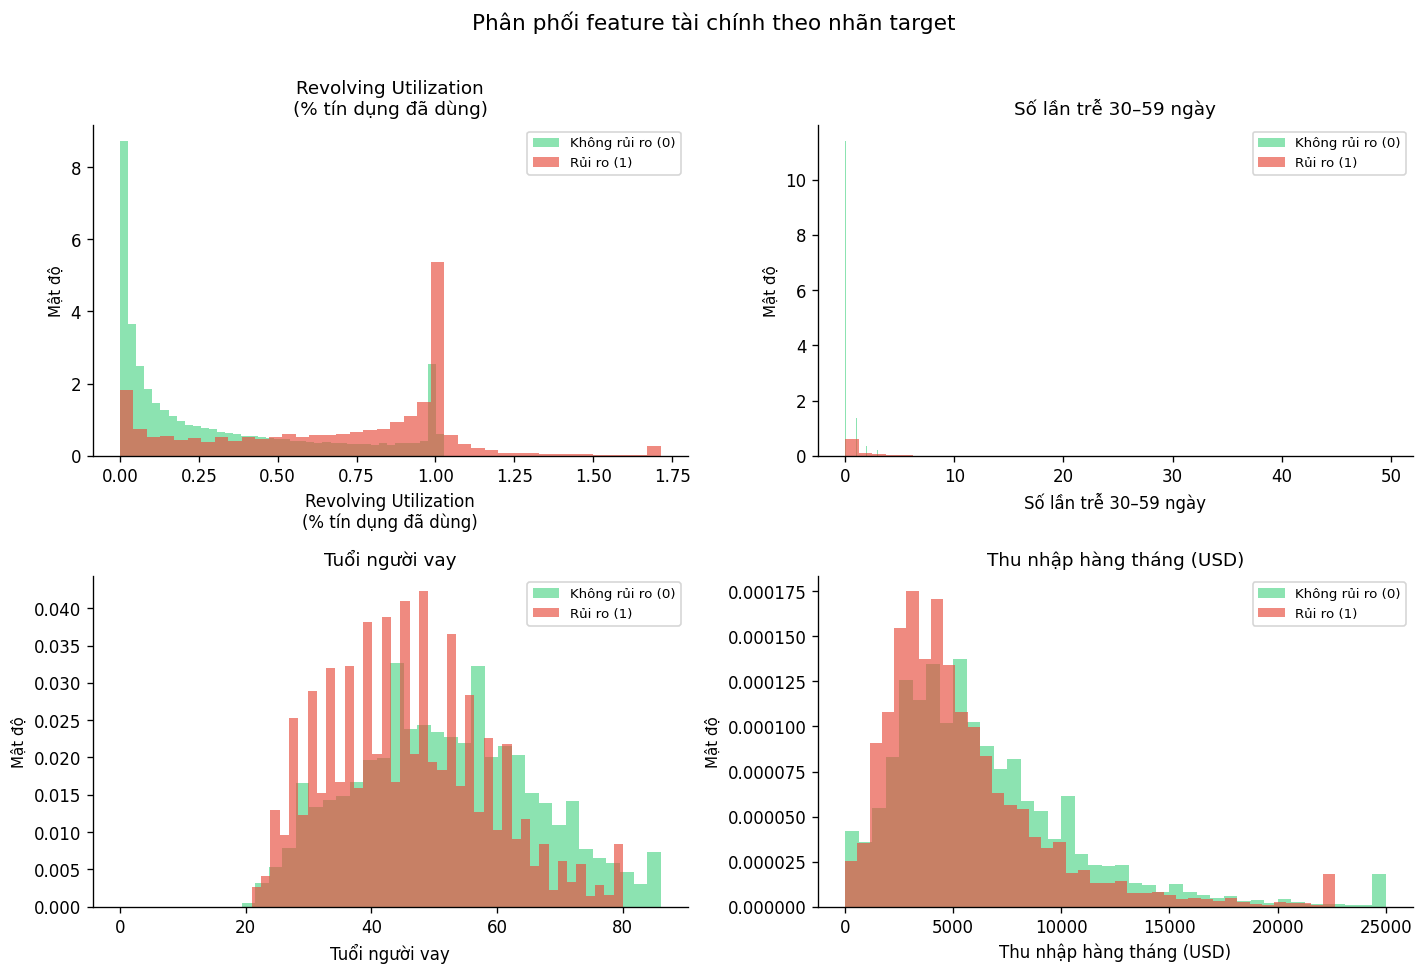

In [7]:
# Bỏ outlier cực đoan để hình dễ đọc (giữ 99th percentile)
def clip_col(series, upper_pct=99):
    cap = series.quantile(upper_pct / 100)
    return series.clip(upper=cap)

FEATURES_TO_PLOT = [
    ('RevolvingUtilizationOfUnsecuredLines',  'Revolving Utilization\n(% tín dụng đã dùng)'),
    ('NumberOfTime30-59DaysPastDueNotWorse',  'Số lần trễ 30–59 ngày'),
    ('age',                                   'Tuổi người vay'),
    ('MonthlyIncome',                         'Thu nhập hàng tháng (USD)'),
]

df_plot = df[[TARGET] + [f for f, _ in FEATURES_TO_PLOT]].dropna()
group0 = df_plot[df_plot[TARGET] == 0]
group1 = df_plot[df_plot[TARGET] == 1]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, (col, label) in zip(axes, FEATURES_TO_PLOT):
    s0 = clip_col(group0[col])
    s1 = clip_col(group1[col])

    ax.hist(s0, bins=40, density=True, alpha=0.55, color=PALETTE[0],
            label='Không rủi ro (0)', edgecolor='none')
    ax.hist(s1, bins=40, density=True, alpha=0.65, color=PALETTE[1],
            label='Rủi ro (1)',        edgecolor='none')

    ax.set_xlabel(label, fontsize=10)
    ax.set_ylabel('Mật độ', fontsize=9)
    ax.set_title(label, fontsize=11)
    ax.legend(fontsize=8)

fig.suptitle('Phân phối feature tài chính theo nhãn target', fontsize=13, y=1.01)
plt.tight_layout()
save_path = os.path.join(OUTPUT_DIR, 'dm_gmsc_key_feature_histograms.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f'Đã lưu: {save_path}')
plt.show()

Các biến liên quan đến lịch sử trễ hạn cho thấy sự khác biệt phân phối đáng kể giữa hai lớp. Điều này gợi ý rằng hành vi thanh toán trong quá khứ có khả năng dự báo rủi ro tín dụng tốt hơn so với các biến nhân khẩu học như tuổi hoặc thu nhập.

---
## 6. Hình 4 – Correlation Heatmap

**Caption:** *Hình 4 – Ma trận tương quan Pearson giữa các biến trong dataset.  
Ba biến trễ hạn (`NumberOfTimes90DaysLate`, `NumberOfTime60-89Days...`, `NumberOfTime30-59Days...`) có tương quan rất cao với nhau (r ≈ 0.98), cho thấy khả năng tồn tại hiện tượng đa cộng tuyến. Đây là yếu tố cần được cân nhắc trong giai đoạn xây dựng mô hình.  
Ba biến phản ánh lịch sử trễ hạn thanh toán (`Late30-59`, `Late60-89` và `Late90+`) có mức tương quan dương cao nhất với biến mục tiêu.*

Đã lưu: outputs\figures\dm_gmsc_correlation_heatmap.png


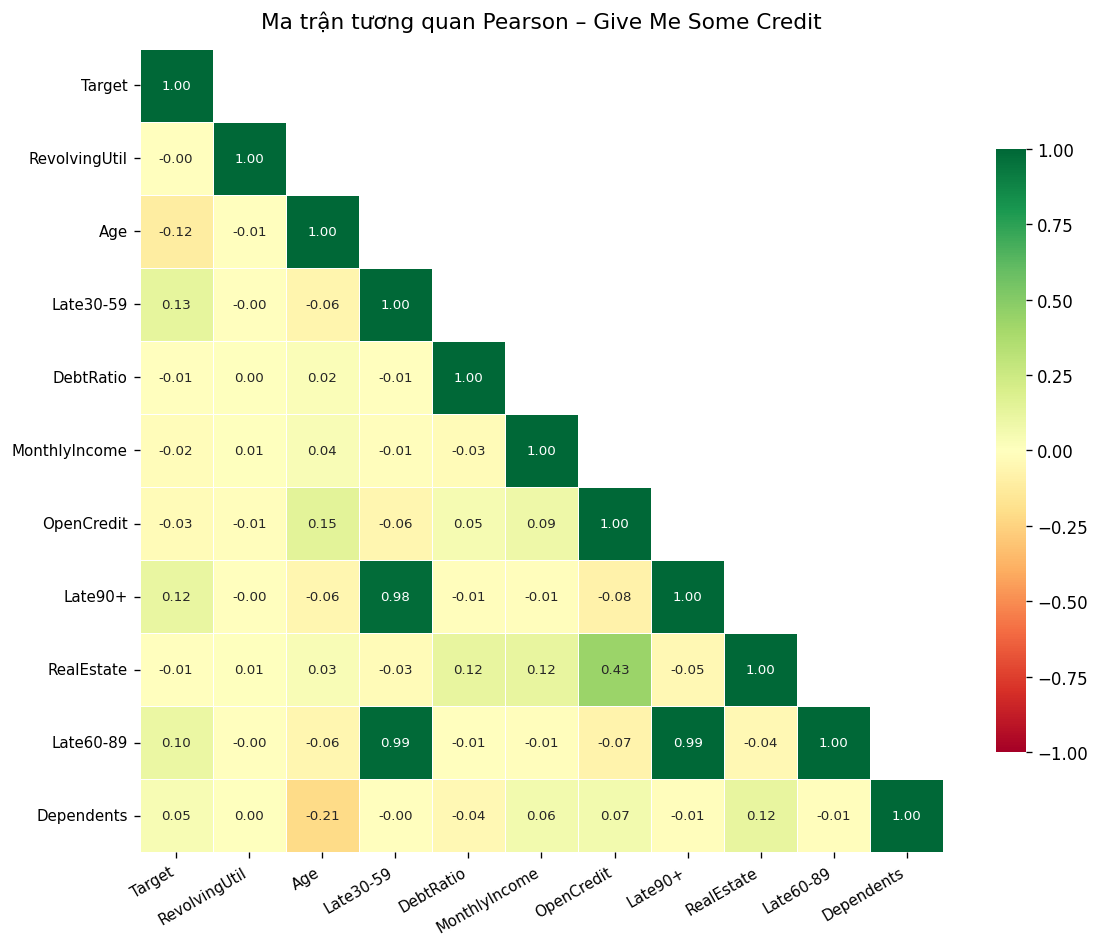

Target           1.000000
Late30-59        0.125587
Late90+          0.117175
Late60-89        0.102261
Dependents       0.046048
RevolvingUtil   -0.001802
RealEstate      -0.007038
DebtRatio       -0.007602
MonthlyIncome   -0.019746
OpenCredit      -0.029669
Age             -0.115386
Name: Target, dtype: float64

In [13]:
# Dùng dữ liệu đã impute median cho missing để corr không bị NaN
df_corr = df.copy()
for col in df_corr.columns:
    if df_corr[col].isna().any():
        df_corr[col].fillna(df_corr[col].median(), inplace=True)

corr = df_corr.corr()

# Rút ngắn tên cột cho dễ đọc
rename_map = {
    'SeriousDlqin2yrs'                      : 'Target',
    'RevolvingUtilizationOfUnsecuredLines'   : 'RevolvingUtil',
    'NumberOfTime30-59DaysPastDueNotWorse'   : 'Late30-59',
    'NumberOfTimes90DaysLate'                : 'Late90+',
    'NumberOfTime60-89DaysPastDueNotWorse'   : 'Late60-89',
    'NumberOfOpenCreditLinesAndLoans'        : 'OpenCredit',
    'NumberRealEstateLoansOrLines'           : 'RealEstate',
    'NumberOfDependents'                     : 'Dependents',
    'DebtRatio'                              : 'DebtRatio',
    'MonthlyIncome'                          : 'MonthlyIncome',
    'age'                                    : 'Age',
}
corr.rename(index=rename_map, columns=rename_map, inplace=True)

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)   # chỉ hiện tam giác dưới

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr,
    mask=mask,
    annot=True, fmt='.2f', annot_kws={'size': 8},
    cmap='RdYlGn', center=0,
    vmin=-1, vmax=1,
    linewidths=0.5, linecolor='white',
    square=True, ax=ax,
    cbar_kws={'shrink': 0.75}
)

ax.set_title('Ma trận tương quan Pearson – Give Me Some Credit', fontsize=13, pad=12)
plt.xticks(rotation=30, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)

plt.tight_layout()
save_path = os.path.join(OUTPUT_DIR, 'dm_gmsc_correlation_heatmap.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f'Đã lưu: {save_path}')
plt.show()

target_corr_col = rename_map.get(TARGET, TARGET)
corr[target_corr_col].sort_values(ascending=False)

---
## 7. Bonus – Boxplot trễ hạn theo target (để hiểu quan hệ rõ hơn)

Hình phụ trợ (không bắt buộc nộp), nhưng hữu ích cho phần nhận xét EDA trong report.

Đã lưu: outputs\figures\dm_gmsc_latepayment_boxplot.png


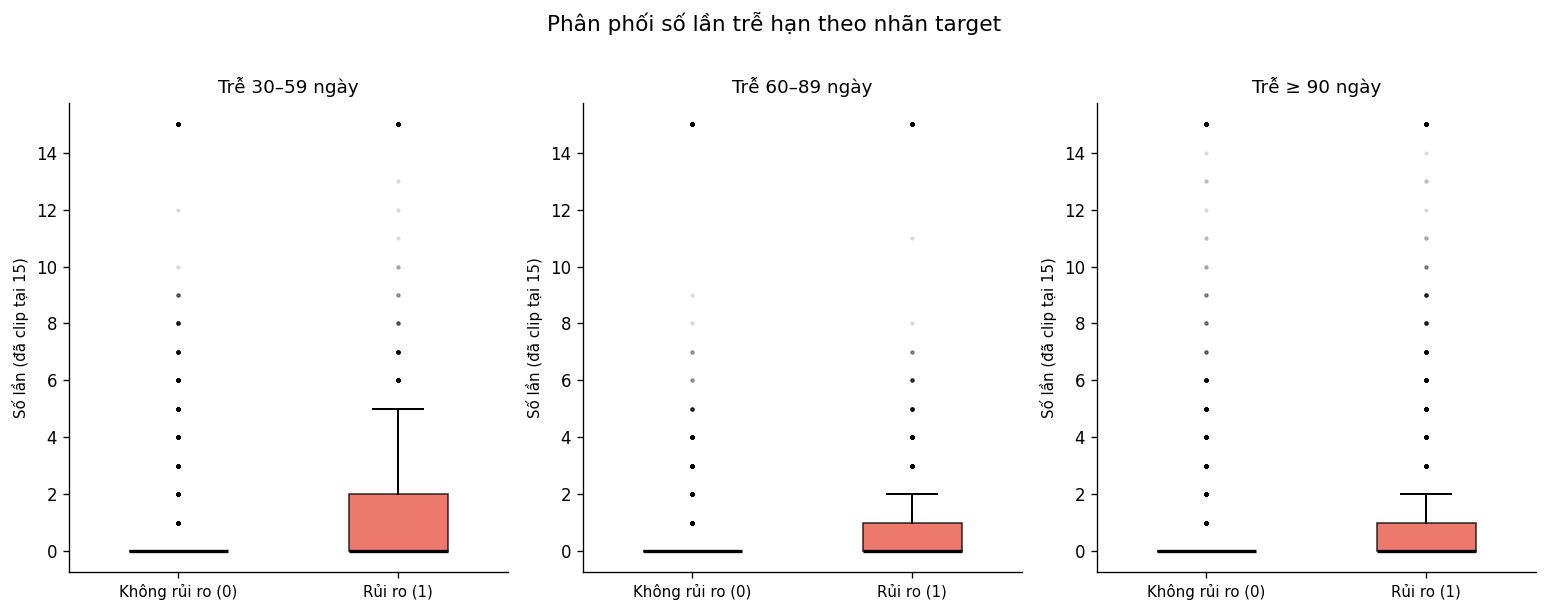

In [9]:
LATE_COLS = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate',
]
SHORT_NAMES = ['Trễ 30–59 ngày', 'Trễ 60–89 ngày', 'Trễ ≥ 90 ngày']

df_box = df[[TARGET] + LATE_COLS].copy()
# Clip outlier 96/98 (data anomaly đã biết)
for col in LATE_COLS:
    df_box[col] = df_box[col].clip(upper=15)

fig, axes = plt.subplots(1, 3, figsize=(13, 5), sharey=False)

for ax, col, name in zip(axes, LATE_COLS, SHORT_NAMES):
    data_0 = df_box[df_box[TARGET] == 0][col]
    data_1 = df_box[df_box[TARGET] == 1][col]

    bp = ax.boxplot(
        [data_0, data_1],
        patch_artist=True,
        widths=0.45,
        medianprops=dict(color='black', linewidth=2),
        whiskerprops=dict(linewidth=1.2),
        capprops=dict(linewidth=1.2),
        flierprops=dict(marker='.', alpha=0.15, markersize=3)
    )
    for patch, color in zip(bp['boxes'], PALETTE):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)

    ax.set_title(name, fontsize=11)
    ax.set_xticks([1, 2])
    ax.set_xticklabels(['Không rủi ro (0)', 'Rủi ro (1)'], fontsize=9)
    ax.set_ylabel('Số lần (đã clip tại 15)', fontsize=9)

fig.suptitle('Phân phối số lần trễ hạn theo nhãn target', fontsize=13, y=1.01)
plt.tight_layout()
save_path = os.path.join(OUTPUT_DIR, 'dm_gmsc_latepayment_boxplot.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f'Đã lưu: {save_path}')
plt.show()

Hình cho thấy nhóm khách hàng rủi ro có số lần trễ hạn cao hơn đáng kể ở cả ba khoảng thời gian 30–59 ngày, 60–89 ngày và trên 90 ngày. Kết quả này phù hợp với trực giác nghiệp vụ rằng lịch sử thanh toán là một trong những tín hiệu quan trọng nhất của nguy cơ vỡ nợ trong tương lai.

---
## 8. Tóm tắt thống kê cơ bản (để tham khảo khi viết report)

In [15]:
# Tỷ lệ class
vc = df[TARGET].value_counts()
print('=== Phân phối target ===')
for k, v in vc.items():
    print(f'  Class {k}: {v:,} ({v/len(df):.2%})')
ir = vc[0] / vc[1]
print(f' Imbalance Ratio (majority/minority) = {ir:.1f}')
print(f' Tỷ lệ minority:majority ≈ 1:{ir:.1f}')
print()

# Missing
print('=== Missing values ===')
miss = df.isna().sum()
miss = miss[miss > 0]
for col, n in miss.items():
    print(f'  {col}: {n:,} ({n/len(df):.2%})')
print()

# Thống kê mô tả của một số biến quan trọng
print('=== Thống kê mô tả (theo target) ===')
key_cols = ['RevolvingUtilizationOfUnsecuredLines', 'age', 'MonthlyIncome']
for col in key_cols:
    g = df.groupby(TARGET)[col].agg(['mean','median','std']).round(3)
    print(f'\n{col}:')
    print(g.to_string())

=== Phân phối target ===
  Class 0: 139,974 (93.32%)
  Class 1: 10,026 (6.68%)
 Imbalance Ratio (majority/minority) = 14.0
 Tỷ lệ minority:majority ≈ 1:14.0

=== Missing values ===
  MonthlyIncome: 29,731 (19.82%)
  NumberOfDependents: 3,924 (2.62%)

=== Thống kê mô tả (theo target) ===

RevolvingUtilizationOfUnsecuredLines:
                   mean  median      std
SeriousDlqin2yrs                        
0                 6.169   0.133  256.126
1                 4.367   0.839  131.836

age:
                    mean  median     std
SeriousDlqin2yrs                        
0                 52.751    52.0  14.791
1                 45.927    45.0  12.916

MonthlyIncome:
                      mean  median        std
SeriousDlqin2yrs                             
0                 6747.838  5466.0  14813.502
1                 5630.826  4500.0   6171.720


---
## 9. Kiểm tra output – Xác nhận đã lưu đủ hình

In [11]:
expected_files = [
    'dm_gmsc_class_distribution.png',
    'dm_gmsc_missing_values.png',
    'dm_gmsc_key_feature_histograms.png',
    'dm_gmsc_correlation_heatmap.png',
    'dm_gmsc_latepayment_boxplot.png',
]

print('=== Kiểm tra file output ===')
all_ok = True
for fname in expected_files:
    fpath = os.path.join(OUTPUT_DIR, fname)
    exists = os.path.exists(fpath)
    status = '✅' if exists else '❌ THIẾU'
    print(f'  {status}  {fpath}')
    if not exists:
        all_ok = False

print()
if all_ok:
    print('Tất cả hình đã lưu thành công! Sẵn sàng nộp cho nhóm.')
else:
    print('Có file chưa được lưu. Chạy lại ô tương ứng phía trên.')

=== Kiểm tra file output ===
  ✅  outputs\figures\dm_gmsc_class_distribution.png
  ✅  outputs\figures\dm_gmsc_missing_values.png
  ✅  outputs\figures\dm_gmsc_key_feature_histograms.png
  ✅  outputs\figures\dm_gmsc_correlation_heatmap.png
  ✅  outputs\figures\dm_gmsc_latepayment_boxplot.png

Tất cả hình đã lưu thành công! Sẵn sàng nộp cho nhóm.


---
## 10. Draft nội dung viết cho report (tiếng Việt)

Copy phần dưới đây vào Google Docs / Word để chỉnh sửa tiếp.

---

### 2.1 Bài toán phân loại với dữ liệu mất cân bằng

Trong bài toán phân loại nhị phân, **mất cân bằng lớp** (class imbalance) xảy ra khi số lượng mẫu thuộc một lớp lớn hơn đáng kể so với lớp còn lại. Lớp chiếm đa số được gọi là **majority class**, lớp thiểu số là **minority class**. Tỷ lệ giữa hai lớp được đo bằng **imbalance ratio** (IR = |majority| / |minority|).

Trong bài toán phát hiện rủi ro tín dụng (dataset *Give Me Some Credit*), tỷ lệ khách hàng rủi ro chỉ chiếm khoảng 6.7% (≈ 10 026 mẫu trên 150 000), tương ứng IR ≈ 1:14.

#### Vì sao accuracy gây hiểu lầm?

Xét ví dụ đơn giản: giả sử có 9 900 mẫu bình thường và 100 mẫu rủi ro. Một model đơn giản chỉ predict toàn bộ là "không rủi ro" vẫn đạt **accuracy = 99%**, trong khi **recall với lớp thiểu số = 0%** – tức là bỏ sót hoàn toàn những người thực sự có nguy cơ vỡ nợ. Điều này cho thấy accuracy là metric không phù hợp để đánh giá model trên dữ liệu mất cân bằng.

#### Các metric phù hợp hơn

- **Precision**: trong số các mẫu được model dự đoán là rủi ro, bao nhiêu phần trăm thực sự rủi ro.
- **Recall (Sensitivity)**: trong số các mẫu thực sự rủi ro, model phát hiện được bao nhiêu phần trăm.
- **F1-score**: trung bình điều hoà của precision và recall. F2-score ưu tiên recall hơn, phù hợp khi chi phí bỏ sót (false negative) cao hơn chi phí báo sai (false positive) – đúng với bài toán tín dụng.
- **PR-AUC**: diện tích dưới đường cong Precision–Recall, phản ánh tổng thể khả năng phân biệt của model ở mọi ngưỡng quyết định.

---

### 3.3 EDA trên Give Me Some Credit

**Phân phối target (Hình 1):** Tập huấn luyện gồm 150 000 mẫu, trong đó 139 974 mẫu thuộc lớp 0 (không có rủi ro nghiêm trọng) và 10 026 mẫu thuộc lớp 1 (có rủi ro tín dụng), tạo ra tỷ lệ minority:majority xấp xỉ 1:14. Đây là mức imbalance đủ mạnh để các model thông thường dễ thiên vị về lớp 0.

**Missing values (Hình 2):** Hai biến có giá trị khuyết thiếu đáng kể: 
`MonthlyIncome` có tỷ lệ thiếu dữ liệu khá lớn (19.82%), trong khi `NumberOfDependents` chỉ thiếu 2.62%. Hai biến này cần được xử lý ở bước tiền xử lý dữ liệu trước khi xây dựng mô hình. Các biến còn lại không có missing values.

**Phân phối feature (Hình 3):** Biến `RevolvingUtilizationOfUnsecuredLines` phân phối lệch phải mạnh và chứa nhiều giá trị ngoại lệ cực đoan. Xét theo trung vị, nhóm khách hàng rủi ro có mức sử dụng hạn mức tín dụng cao hơn đáng kể so với nhóm không rủi ro. Tuy nhiên giá trị trung bình bị ảnh hưởng mạnh bởi các ngoại lệ nên không phản ánh đầy đủ xu hướng phân phối của biến này. Biến `age` và `MonthlyIncome` cũng cho thấy sự khác biệt nhất định giữa hai nhóm. Cụ thể, khách hàng thuộc nhóm rủi ro có xu hướng trẻ hơn và có thu nhập trung vị thấp hơn so với nhóm không rủi ro. Tuy nhiên, mức độ tách biệt của hai biến này vẫn thấp hơn đáng kể so với các biến liên quan đến lịch sử trễ hạn thanh toán.

**Correlation heatmap (Hình 4):** Ba biến trễ hạn (`NumberOfTimes90DaysLate`, `NumberOfTime60-89DaysPastDueNotWorse`, `NumberOfTime30-59DaysPastDueNotWorse`) có tương quan Pearson rất cao với nhau (r ≈ 0.98), cho thấy chúng mang thông tin tương đồng. Đây là dấu hiệu cho thấy các biến mang thông tin tương đồng và có thể được xem xét để giảm dư thừa đặc trưng hoặc xây dựng các đặc trưng tổng hợp trong giai đoạn xây dựng mô hình. 
Ba biến phản ánh lịch sử trễ hạn thanh toán (`Late30-59`, `Late60-89` và `Late90+`) có mức tương quan dương cao nhất với biến mục tiêu, cho thấy hành vi trả nợ trong quá khứ là tín hiệu quan trọng để dự đoán rủi ro tín dụng. Ngược lại, tuổi khách hàng (Age) có tương quan âm với target, hàm ý nhóm khách hàng trẻ tuổi có xu hướng xuất hiện tỷ lệ vỡ nợ cao hơn.

---